<a href="https://colab.research.google.com/github/xabierblanch/EGG_FotogrametriaTerrestre/blob/main/FMT_S2_Homografia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#HOMOGRAFIA - Exercicis pràctics

##Rectificació Mètrica

La **homografia** ($H_{3\times3}$) és una transformació projectiva lineal que relaciona dos plans bidimensionals ($\mathbb{P}^2 \rightarrow \mathbb{P}^2$).

A diferència de la matriu de projecció general $P_{3\times4}$ (que redueix el món 3D a una imatge 2D i perd la informació de profunditat), quan tots els punts d'interès d'un objecte o escena pertanyen a un **únic pla** (per exemple, $Z=0$), la relació entre les coordenades de la imatge i les coordenades del món real és biunívoca i invertible:

$$\lambda \begin{bmatrix} u \\ v \\ 1 \end{bmatrix} = H_{3\times3} \begin{bmatrix} X \\ Y \\ 1 \end{bmatrix} = \begin{bmatrix} h_{11} & h_{12} & h_{13} \\ h_{21} & h_{22} & h_{23} \\ h_{31} & h_{32} & h_{33} \end{bmatrix} \begin{bmatrix} X \\ Y \\ 1 \end{bmatrix}$$

On:
- $(u, v)$ són les coordenades en píxels a la imatge.
- $(X, Y)$ són les coordenades reals en el pla (ex. en cm o metres).
- $\lambda$ és un factor d'escala projectiu.

---

###0.- Configuració de l'Entorn i Llibreries

A continuació importem totes les llibreries que utilitzarem al llarg de la pràctica. Executa aquesta cel·la per comprovar que l'entorn de Python està correctament configurat.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Configuració de la visualització de matplotlib
plt.rcParams['figure.figsize'] = [10, 8]
print("Entorn configurat correctament amb OpenCV", cv2.__version__)

!pip install -q pillow-heif #(pels que veniu amb iphone a classe! :D)
from PIL import Image
import pillow_heif

###1.- Càrrega de la imatge

Fes una imatge de l'objecte que volem mesurar. Recorda que ha de ser un pla. Pots realitzar la imatge amb una certa oblicuitat per comprovar la robustressa del sistema (una fotografia zenital no té cap gràcia).

1. Fes una fotografia d'un objecte pla (un llibre, un full de paper, una rajola, etc.) situat sobre una superfície plana.
2. Fes la foto amb certa **perspectiva/oblicuïtat** (evita fer una foto completament zenital) per poder comprovar la capacitat de rectificació de la homografia.
3. Executa la cel·la següent per carregar la imatge des del teu ordinador.

In [ ]:
# Registrar el soporte para archivos HEIC/HEIF en PIL
pillow_heif.register_heif_opener()

print("Si us plau, carrega la foto del teu llibre sobre la taula (JPG, PNG, HEIC...):")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Leer la imagen con PIL (sirve tanto para JPG/PNG como para HEIC/HEIF)
img_pil = Image.open(filename)

# Convertir la imagen a un array de NumPy en formato RGB para Matplotlib/OpenCV
img_rgb = np.array(img_pil.convert('RGB'))

plt.imshow(img_rgb)
plt.title("Imatge original (Perspectiva de la càmara)")
plt.axis('on')
plt.show()

### 2.- Definició de punts de control (Image vs Mètric)

Per resoldre els 8 graus de llibertat de la matriu $H$, necessitem com a mínim 4 punts no col·lineals dels quals coneguem:

*   Les seves coordenades en píxels a la imatge $(u_i, v_i)$.
*   Les seves coordenades mètriques reals sobre el pla del llibre $(X_i, Y_i)$ en mm o cm.

Les coordenades de la imatge es poden indentificar fent servir el Paint, o un visor fotogràfic que mostri les coordenades del cursor.

En aquesta cel·la has de definir **únicament i exclusivament** els punts d'interès.

- `pts_imatge`: Identifica les coordenades $(u, v)$ en píxels dels 4 de cantons de l'objecte pla (p. ex., la teva llibreta o llibre).
- `amplada_mm`: l'amplada del llibre o el pla que estiguis mesurant
- `alçada_mm`: l'alçada del llibre o el pla que estiguis mesurant

(aquest exercici assumeix que el llibre o el pla és un rectangle. Les coordenades reals del pla queden definides a `pts_real`)

In [ ]:
pts_image = np.array([
    [1537, 1720],  # Cantó superior esquerre
    [2219, 2013],  # Cantó superior dret
    [1649, 2796],  # Cantó inferior dret
    [833,  2309]   # Cantó inferior esquerre
], dtype=np.float32)

# DEFINIR LES MIDES REALS DEL LLIBRE (X, Y) en mil·límetres
# Exemple: Llibre DIN A4 o mida real mesurada amb regle/flexòmetre
amplada_mm = 247.0
alçada_mm = 297.0

pts_real = np.array([
    [0.0, 0.0],
    [amplada_mm, 0.0],
    [amplada_mm, alçada_mm],
    [0.0, alçada_mm]
], dtype=np.float32)

# Visualització dels punts seleccionats sobre la imatge
plt.imshow(img_rgb)
plt.scatter(pts_image[:, 0], pts_image[:, 1], c='red', s=50, marker='x')
for i, txt in enumerate(['P1(0,0)', 'P2(w,0)', 'P3(w,h)', 'P4(0,h)']):
    plt.annotate(txt, (pts_image[i, 0]+10, pts_image[i, 1]+10), color='yellow', fontsize=12, fontweight='bold')
plt.title("Punts de Control seleccionats sobre la imatge (u, v)")
plt.show()

print("Punts imatge (px):\n", pts_image)
print("\nPunts reals (mm):\n", pts_real)

### 3.- Càlcul de la Matriu H pas a pas (Algoritme DLT)

Estimació de la Homografia "A Mà" (DLT - Direct Linear Transform)Desenvolupem el sistema d'equacions $A \cdot h = 0$ a partir de les dues equacions que aporta cada punt $i$:$$X_i h_{11} + Y_i h_{12} + h_{13} - u_i X_i h_{31} - u_i Y_i h_{32} - u_i h_{33} = 0$$$$X_i h_{21} + Y_i h_{22} + h_{23} - v_i X_i h_{31} - v_i Y_i h_{32} - v_i h_{33} = 0$$

In [ ]:
def construir_sistema_dlt(pts_src, pts_dst):
    """
    Construeix i mostra pas a pas la matriu A del sistema A*h = 0.

    pts_src: Punts del món real (X, Y)
    pts_dst: Punts de la imatge (u, v)
    """
    A = []

    print("=" * 80)
    print(" PAS 3.1: ESTRUCTURA FORMAL DEL SISTEMA D'EQUACIONS A·h = 0")
    print("=" * 80)
    print("Les 9 incògnites són: [h11, h12, h13, h21, h22, h23, h31, h32, h33]^T\n")
    print("Per a cada punt i, s'obtenen 2 equacions:")
    print("  Eq. u:  X_i·h11 + Y_i·h12 + h13 - u_i·X_i·h31 - u_i·Y_i·h32 - u_i·h33 = 0")
    print("  Eq. v:  X_i·h21 + Y_i·h22 + h23 - v_i·X_i·h31 - v_i·Y_i·h32 - v_i·h33 = 0\n")
    print("=" * 80)
    print(" PAS 3.2: SUBSTITUCIÓ NUMÈRICA PUNT A PUNT")
    print("=" * 80)

    for i in range(len(pts_src)):
        X, Y = pts_src[i][0], pts_src[i][1]
        u, v = pts_dst[i][0], pts_dst[i][1]

        # Fila 1 (Component u)
        fila_u = [X, Y, 1, 0, 0, 0, -u*X, -u*Y, -u]
        # Fila 2 (Component v)
        fila_v = [0, 0, 0, X, Y, 1, -v*X, -v*Y, -v]

        A.append(fila_u)
        A.append(fila_v)

        print(f"(u): [{X:6.1f}·h11 + {Y:6.1f}·h12 + 1·h13 + 0 + 0 + 0 + {-u*X:8.1f}·h31 + {-u*Y:8.1f}·h32 + {-u:6.1f}·h33 = 0]")
        print(f"(v): [0 + 0 + 0 + {X:6.1f}·h21 + {Y:6.1f}·h22 + 1·h23 + {-v*X:8.1f}·h31 + {-v*Y:8.1f}·h32 + {-v:6.1f}·h33 = 0]")

    A = np.array(A)

    print("\n" + "=" * 80)
    print(" PAS 3.3: MATRIU A COMPLETA (8 files x 9 columnes)")
    print("=" * 80)
    for idx, fila in enumerate(A):
        component = "u" if idx % 2 == 0 else "v"
        punt_num = (idx // 2) + 1
        valors_str = "  ".join([f"{val:9.1f}" for val in fila])
        print(f"Punt {punt_num} ({component}) | {valors_str}")

    return A

matriu_A = construir_sistema_dlt(pts_real, pts_image)

In [ ]:
def resoldre_homografia_svd(A):
    """
    Resol el sistema A*h = 0 mitjançant Descomposició en Valors Singulares (SVD).

    A: Matriu de disseny (8x9)
    """
    # Resolució del sistema A*h = 0 mitjançant SVD
    U, S, Vt = np.linalg.svd(A)

    # La solució h és el darrer vector propi (última fila de Vt)
    h = Vt[-1]

    # Normalització respecte a h33
    H = h.reshape((3, 3))
    H = H / H[2, 2]

    print("\nMATRIU DE HOMOGRAFIA FINAL (H = H / h33):\n", H)

    return H

H_manual = resoldre_homografia_svd(matriu_A)

###4.- Calcul de la matriu H fent servir la funció d'OpenCV

Calculem el resultat utilitzant la funció optimitzada cv2.findHomography().

In [ ]:
H_opencv, _ = cv2.findHomography(pts_real, pts_image)

print("Matriu H OpenCV:\n", H_opencv)


###5.- Comprovació diferències entre el mètode manual (sistema d'equacións) i la funció d'OpenCV


In [ ]:
print("\nDiferència absoluta entre mètodes:\n", np.abs(H_manual - H_opencv))

# Comprovació d'error residual mitjà
error_residual = np.mean(np.abs(H_manual - H_opencv))
print(f"\nError mitjà d'ajust entre els dos mètodes: {error_residual:.8f}")

###6.- Generació de la imatge rectificada (Vista Cenital)

### Concepte clau: Mapeig directe vs. Mapeig invers (*Backward Mapping*)

A les seccions anteriors hem calculat la matriu $H$, la qual relaciona les coordenades del pla real amb la imatge original:

$$\mathbf{x}_{img} = H \cdot \mathbf{X}_{real}$$

No obstant això, per generar la imatge rectificada fem servir la matriu **inversa** $H^{-1}$ (o l'opció `WARP_INVERSE_MAP` de OpenCV). Aquest procés s'anomena **mapeig invers** (*backward mapping*):

1. **Mapeig directe:** Si transforméssim cada píxel de la imatge original cap a la nova imatge, molts píxels de la imatge rectificada quedarien buits (efecte "forats") a causa del canvi d'escala i la deformació projectiva.

2. **Mapeig invers:** Recorrem cada posició $(X, Y)$ de la nova imatge rectificada i utilitzem $H$ (o $H^{-1}$) per consultar quin píxel de la imatge original li correspon, aplicant una interpolació de color.

In [ ]:
h_orig, w_orig = img_rgb.shape[:2]

esquinas_orig = np.array([
    [0, 0],
    [w_orig, 0],
    [w_orig, h_orig],
    [0, h_orig]
], dtype=np.float32).reshape(-1, 1, 2)

H_inv = np.linalg.inv(H_manual)
esquinas_transformadas = cv2.perspectiveTransform(esquinas_orig, H_inv)

x_min, y_min = esquinas_transformadas[:, 0, :].min(axis=0)
x_max, y_max = esquinas_transformadas[:, 0, :].max(axis=0)

T = np.array([
    [1, 0, -x_min],
    [0, 1, -y_min],
    [0, 0, 1]
], dtype=np.float32)

H_completa = T @ H_inv

ancho_lienzo = int(np.ceil(x_max - x_min))
alto_lienzo = int(np.ceil(y_max - y_min))

img_rectificada_completa = cv2.warpPerspective(
    img_rgb,
    H_completa,
    (ancho_lienzo, alto_lienzo)
)

# ------------------------------------------------------------------------------
# 2. IMATGE RECTIFICADA CENTRADA AMB MARGE (DETALL CONTEXTUAL)
# ------------------------------------------------------------------------------
marge_mm = 100.0  # Marge de 100 mm per cada costat

pts_real_marge = np.array([
    [0.0 + marge_mm, 0.0 + marge_mm],
    [amplada_mm + marge_mm, 0.0 + marge_mm],
    [amplada_mm + marge_mm, alçada_mm + marge_mm],
    [0.0 + marge_mm, alçada_mm + marge_mm]
], dtype=np.float32)

H_marge, _ = cv2.findHomography(pts_real_marge, pts_image)

res_x_marge = int(amplada_mm + 2 * marge_mm)
res_y_marge = int(alçada_mm + 2 * marge_mm)

img_rectificada_context = cv2.warpPerspective(
    img_rgb,
    H_marge,
    (res_x_marge, res_y_marge),
    flags=cv2.WARP_INVERSE_MAP
)

# ------------------------------------------------------------------------------
# 3. VISUALITZACIÓ UNIFICADA EN UN SUBPLOT DE 1x3 (NOU ORDRE)
# ------------------------------------------------------------------------------
plt.figure(figsize=(20, 7))

# Subplot 1: Imatge Original
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("1. Original (Perspectiva)")
plt.xlabel("u (px)")
plt.ylabel("v (px)")

# Subplot 2: Escena Completa Deformada
plt.subplot(1, 3, 2)
plt.imshow(img_rectificada_completa)
plt.title(f"2. Escena Completa ({ancho_lienzo}x{alto_lienzo} mm)")
plt.xlabel("X despl. (mm)")
plt.ylabel("Y despl. (mm)")

# Subplot 3: Centrada amb Marge
plt.subplot(1, 3, 3)
plt.imshow(
    img_rectificada_context,
    extent=[-marge_mm, amplada_mm + marge_mm, alçada_mm + marge_mm, -marge_mm]
)
plt.axvline(0, color='red', linestyle='--', alpha=0.6)
plt.axvline(amplada_mm, color='red', linestyle='--', alpha=0.6)
plt.axhline(0, color='red', linestyle='--', alpha=0.6)
plt.axhline(alçada_mm, color='red', linestyle='--', alpha=0.6)
plt.title(f"3. Centrada amb Marge ({res_x_marge}x{res_y_marge} mm)")
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")

plt.tight_layout()
plt.show()

###7.- Descàrrega de la imatge transformada - Resolució 1mm/1px

In [ ]:
nombre_archivo_escena = "escena_completa_deformada_1px_1mm.png"
img_completa_bgr = cv2.cvtColor(img_rectificada_completa, cv2.COLOR_RGB2BGR)
cv2.imwrite(nombre_archivo_escena, img_completa_bgr)
files.download(nombre_archivo_escena)

### 8.- Comprovació dels resultats (Avaluació Mètrica)

Obre la imatge rectificada que t'has descarregat (`escena_completa_deformada_1px_1mm.png`) amb un visor d'imatges o editor (com Paint, GIMP o Photoshop) que et permeti consultar les coordenades del cursor en píxels:

1. Identifica dos punts ($A$ i $B$) sobre la imatge dels quals coneguis la distància real (o que puguis mesurar fàcilment). I anota la mesura obtinguda.
2. Substitueix les coordenades $(u, v)$ obtingudes a les variables `p1` i `p2` del codi següent.
3. Com que la imatge s'ha generat a una escala exacta de **1 px = 1 mm**, la distància euclidiana calculada entre `p1` i `p2` equivaldrà directament a la distància real en mil·límetres.

> ⚠️ **Atenció:** Assegura't de canviar els valors d'exemple de `p1` i `p2` per les coordenades reals mesurades a la teva imatge descarregada.

In [ ]:
# 1. COORDENADES DELS DOS PUNTS A MESURAR (en píxels del llenç complet)
p1 = np.array([4056, 8574], dtype=np.float64)
p2 = np.array([4160, 8574], dtype=np.float64)
####


dist_mm = np.linalg.norm(p2 - p1)
print(f"Distància mesurada: {dist_mm:.1f} mm ({dist_mm/10.0:.2f} cm)")

pts_lienzo = pts_real - np.array([x_min, y_min])
u_min, v_min = pts_lienzo.min(axis=0)
u_max, v_max = pts_lienzo.max(axis=0)

aire = 100.0

plt.figure(figsize=(10, 10))
plt.imshow(img_rectificada_completa)

plt.plot([p1[0], p2[0]], [p1[1], p2[1]], color='cyan', lw=3, label=f"Mesura: {dist_mm:.1f} mm")
plt.scatter([p1[0], p2[0]], [p1[1], p2[1]], color='yellow', s=80, zorder=5, edgecolors='black')

plt.text(int(p1[0]), int(p1[1]) - 15, f"P1 ({int(p1[0])}, {int(p1[1])})",
         color='yellow', fontsize=10, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.8),
         ha='center', va='bottom')

plt.text(int(p2[0]), int(p2[1]) + 15, f"P2 ({int(p2[0])}, {int(p2[1])})",
         color='yellow', fontsize=10, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.8),
         ha='center', va='top')

plt.xlim(u_min - aire, u_max + aire)
plt.ylim(v_max + aire, v_min - aire)  # Invertit per a coordenades d'imatge

plt.title(f"Comprovació de la mesura: {dist_mm:.1f} mm ({dist_mm/10.0:.2f} cm)")
plt.xlabel("X en la imatge completa (px / mm)")
plt.ylabel("Y en la imatge completa (px / mm)")
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()

### 9.- Comprovació de l'Error de Reprojecció (Residus en els GCPs)

En qualsevol procés de transformació geomètrica o fotogramètrica, l'**error de reprojecció** mesura la discrepància entre la posició real d'un punt a la imatge ($u, v$) i la posició on la matriu d'homografia calculada ($H$) al tornar a projectar a partir de les seves coordenades mètriques ($X, Y$).

## Interpretació matemàtica del resultat (RMSE = 0.00 px)

Un residu exactament igual a **0.00 px** en els 4 punts de control és el comportament teòric esperat per a aquest cas per les següents raons:

1. **Nombre de graus de llibertat:** Una matriu d'homografia $H_{3\times3}$ té **8 graus de llibertat** (9 elements menys 1 per l'escala homogènia).

2. **Determinació del sistema d'equacions:** Com que cada punt de control ($GCP$) aporta 2 equacions independents (component $u$ i component $v$), 4 punts de control generen un sistema determinat de **8 equacions amb 8 incògnites** ($A \cdot h = 0$).

3. **Ajust exacte:** Quan el nombre d'equacions coincideix exactament amb el nombre d'incògnites, el sistema no està sobredeterminat i existeix una solució única on la transformació passa de manera matemàticament perfecta pels 4 punts originals.

In [ ]:
# Convertim els punts reals a coordenades homogènies [X, Y, 1]^T
pts_real_homo = np.hstack([pts_real, np.ones((len(pts_real), 1))])

# Projectem amb H_manual: p_img_calc = H * P_real
pts_calc_homo = (H_manual @ pts_real_homo.T).T

# Normalitzem per la tercera coordenada z (divisió homogènia)
pts_calc = pts_calc_homo[:, :2] / pts_calc_homo[:, 2:]

# Calculem la distància en píxels entre el punt clicat i el punt teòric
errors_px = np.linalg.norm(pts_image - pts_calc, axis=1)

print("=" * 65)
print("🎯 RESIDUS EN ELS PUNTS DE CONTROL (ERROR DE REPROJECCIÓ)")
print("=" * 65)
for i in range(len(pts_real)):
    print(f" Punt {i+1}: Desviació = {errors_px[i]:.2f} px")
print(f"\n Error mitjà de reprojecció (RMSE): {np.mean(errors_px):.2f} px")
print("=" * 65)

##Invariància Mètrica

En aquesta segona part de la pràctica comprovarem la propietat més potent de la fotogrametria i la homografia: la **invariància mètrica respecte al punt de vista**.

Si prenem dues fotografies de la mateixa carpeta des d'angles de visió completament diferents (per exemple, una des de la meitat esquerra de la taula i una altra des de la meitat dreta) i les rectifiquem totes dues cap al **mateix sistema de coordenades reals $(X, Y)$ en mm**, la perspectiva desapareix.

En superposar les dues imatges rectificades amb un **$50\%$ de transparència**, veurem com les textures, textos i cantonades de la carpeta **coincideixen exactament píxel a píxel**, demostrant que el resultat rectificat és independent de la posició de la càmera.


###1.- Càrrega de les imatges
Executa la cel·la següent per carregar les dues imatges des del teu dispositiu:
1. **Foto 1:** Feta des de la meitat esquerra.
2. **Foto 2:** Feta des de la meitat dreta.

In [ ]:
pillow_heif.register_heif_opener()

print("1. Carrega la PRIMERA foto de la carpeta (perspectiva ESQUERRA):")
up1 = files.upload()
img1_rgb = np.array(Image.open(list(up1.keys())[0]).convert('RGB'))

print("\n2. Carrega la SEGONA foto de la carpeta (perspectiva DRETA):")
up2 = files.upload()
img2_rgb = np.array(Image.open(list(up2.keys())[0]).convert('RGB'))

###2.- Definició de paràmetres mètrics i coordenades
En aquesta cel·la definim les dimensions reals del pla (`amplada_mm` i `alçada_mm`) i un marge per poder veure el context de la taula.

A continuació, has d'introduir les coordenades $(u, v)$ en píxels de les 4 cantonades del pla per a cada imatge.

> ⚠️ **Molt important:** Usa exactament el mateix ordre de punts a les dues imatges:
> 1. **P1:** Cantó superior esquerre $(0, 0)$
> 2. **P2:** Cantó superior dret $(W, 0)$
> 3. **P3:** Cantó inferior dret $(W, H)$
> 4. **P4:** Cantó inferior esquerre $(0, H)$

In [ ]:
amplada_mm = 240.0   # Ajusta a l'amplada real de la carpeta en mm
alçada_mm = 320.0    # Ajusta a l'alçada real de la carpeta en mm
marge_mm = 40.0      # Marge per veure el context de la taula

pts_real_marge = np.array([
    [0.0 + marge_mm, 0.0 + marge_mm],
    [amplada_mm + marge_mm, 0.0 + marge_mm],
    [amplada_mm + marge_mm, alçada_mm + marge_mm],
    [0.0 + marge_mm, alçada_mm + marge_mm]
], dtype=np.float32)

# ------------------------------------------------------------------------------
# PUNTS DE CONTROL EN LES DUES IMATGES (Modificar segons les teves imatges)
# ------------------------------------------------------------------------------
# Punts (u,v) de la carpeta a la Foto 1 (Esquerra)
pts_img1 = np.array([
    [830, 2171],  # Sup. Esquerre
    [1249, 1790],  # Sup. Dret
    [2149, 2106],  # Inf. Dret
    [1917,  2620]   # Inf. Esquerre
], dtype=np.float32)

# Punts (u,v) de la carpeta a la Foto 2 (Dreta)
pts_img2 = np.array([
    [1840,  1456],  # Sup. Esquerre
    [2354, 1943],  # Sup. Dret
    [1314, 2459],  # Inf. Dret
    [880,  1801]   # Inf. Esquerre
], dtype=np.float32)

###3- Comprovació visual dels punts (*Double Check*)
Abans de realitzar cap càlcul matemàtic, és fonamental verificar que no ens hem equivocat en introduir cap coordenada ni hem canviat l'ordre dels punts.

Executa aquesta cel·la per veure les dues fotos originals amb els punts marcats i el polígon de la carpeta dibuixat. Si veus algun punt fora de lloc o les línies creuades, **torna al Pas 2 i corregeix els valors**.

In [ ]:
def dibuixar_punts_i_poligon(ax, img, pts, titol):
    ax.imshow(img)
    # Dibuixar el polígon tancat
    pts_closed = np.vstack([pts, pts[0]])
    ax.plot(pts_closed[:, 0], pts_closed[:, 1], color='cyan', linewidth=2, linestyle='--')

    # Dibuixar els punts i les etiquetes
    etiquetes = ['P1 (0,0)', 'P2 (w,0)', 'P3 (w,h)', 'P4 (0,h)']
    for i, (u, v) in enumerate(pts):
        ax.scatter(u, v, color='red', s=70, zorder=5, edgecolors='white')
        ax.annotate(etiquetes[i], (u + 15, v + 15), color='yellow',
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.6))

    ax.set_title(titol)
    ax.set_xlabel("u (px)")
    ax.set_ylabel("v (px)")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
dibuixar_punts_i_poligon(axes[0], img1_rgb, pts_img1, "Foto 1 (Esquerra) - Punts Seleccionats")
dibuixar_punts_i_poligon(axes[1], img2_rgb, pts_img2, "Foto 2 (Dreta) - Punts Seleccionats")
plt.tight_layout()
plt.show()

###4.- Càlcul de les matrius d'homografia ($H_1$ i $H_2$)
Ara utilitzarem la funció `cv2.findHomography()` d'OpenCV per calcular les dues matrius de transformació:
* $H_1$: Relaciona el pla real en mm amb la **Foto 1** (Esquerra).
* $H_2$: Relaciona el mateix pla real en mm amb la **Foto 2** (Dreta).

Aquestes matrius seran la "clau" matemàtica per eliminar la deformació de la perspectiva de cada càmera.

In [ ]:
H1, _ = cv2.findHomography(pts_real_marge, pts_img1)
H2, _ = cv2.findHomography(pts_real_marge, pts_img2)

res_x = int(amplada_mm + 2 * marge_mm)
res_y = int(alçada_mm + 2 * marge_mm)

# Rectificar totes dues imatges al mateix espai mètric
rect1 = cv2.warpPerspective(img1_rgb, H1, (res_x, res_y), flags=cv2.WARP_INVERSE_MAP)
rect2 = cv2.warpPerspective(img2_rgb, H2, (res_x, res_y), flags=cv2.WARP_INVERSE_MAP)

# FUSIÓ: 50% Foto 1 + 50% Foto 2
imatge_fosa = cv2.addWeighted(rect1, 0.5, rect2, 0.5, 0)

print("MATRIU D'HOMOGRAFIA H1 (Foto 1 - Esquerra):")
print(np.array2string(H1, formatter={'float_kind': lambda x: f"{x:14.6f}"}))


print("\nMATRIU D'HOMOGRAFIA H2 (Foto 2 - Dreta):")
print(np.array2string(H2, formatter={'float_kind': lambda x: f"{x:14.6f}"}))



###5.- Generació de les ortofotos i fusió mètrica (50% / 50%)
Apliquem la transformació projectiva inversa a totes dues imatges per dibuixar-les sobre una **única imatge global** definit a una escala exacta de **1 px = 1 mm**.

A la tercera imatge es combinaran les dues fotos rectificades amb un **50% de transparència**. Si l'ajust fotogramètric és correcte, veuràs com les textures, textos i línies del pla **coincideixen exactament al píxel**, demostrant que el resultat final és independent de la posició de la càmera.

In [ ]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(rect1)
plt.title("1. Rectificació des de l'Esquerra")
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")

plt.subplot(1, 3, 2)
plt.imshow(rect2)
plt.title("2. Rectificació des de la Dreta")
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")

plt.subplot(1, 3, 3)
plt.imshow(imatge_fosa)
plt.axvline(marge_mm, color='red', linestyle='--', alpha=0.5)
plt.axvline(amplada_mm + marge_mm, color='red', linestyle='--', alpha=0.5)
plt.axhline(marge_mm, color='red', linestyle='--', alpha=0.5)
plt.axhline(alçada_mm + marge_mm, color='red', linestyle='--', alpha=0.5)
plt.title("3. Superposició (50% / 50%) - Coincidència Mètrica")
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")

plt.tight_layout()
plt.show()

#Inserció d'Imatge en Pantalla (Realitat Augmentada)

En aquest exercici realitzarem el procés invers: en lloc d'extreure un pla contingut en una foto per rectificar-lo, agafarem la imatge plana de la nostra carpeta i la **projectarem amb la perspectiva correcta** dins de la pantalla d'un ordinador portàtil o monitor.

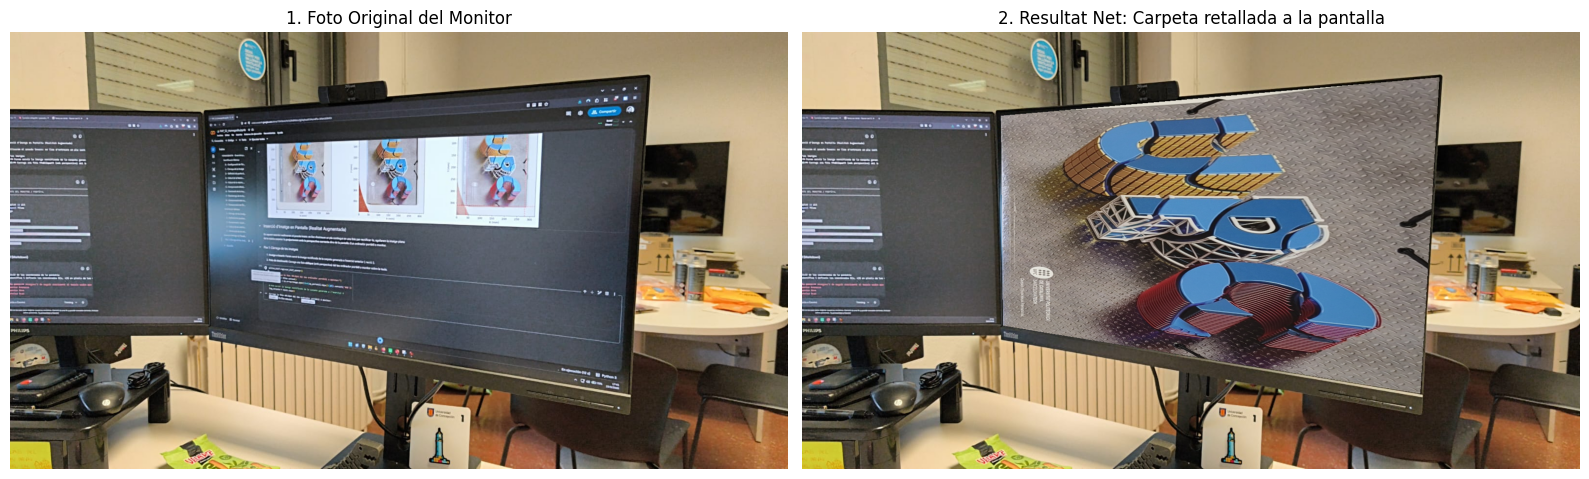

###1.- Càrrega de les imatges
1. **Imatge a inserir:** Farem servir la imatge rectificada de la carpeta generada a l'exercici anterior (`rect1`).

2. **Foto de destinació:** Carrega una foto **obliqua** (amb perspectiva) del teu ordinador portàtil o monitor sobre la taula.

In [ ]:
print("1. Carrega la foto de pla:")
up_pla = files.upload()
foto_pla = np.array(Image.open(list(up_pla.keys())[0]).convert('RGB'))

print("\n2. Carrega la foto de la pantalla:")
up_pantalla = files.upload()
foto_pantalla = np.array(Image.open(list(up_pantalla.keys())[0]).convert('RGB'))

###2.- Definició de les coordenades de la pantalla
A continuació, identifica i defineix les coordenades $(u, v)$ en píxels de les **4 cantonades interiors del marc de la pantalla** a la foto del portàtil.

> ⚠️ **Ordre dels punts:** Assegura't de seguir exactament el mateix ordre que a la imatge origen:
> 1. **P1:** Superior Esquerre
> 2. **P2:** Superior Dret
> 3. **P3:** Inferior Dret
> 4. **P4:** Inferior Esquerre

In [ ]:
pts_pla = np.array([
    [1537, 1720],  # Cantó superior esquerre
    [2219, 2013],  # Cantó superior dret
    [1649, 2796],  # Cantó inferior dret
    [833,  2309]   # Cantó inferior esquerre
], dtype=np.float32)

pts_pantalla = np.array([
    [409,  174],   # P1: Sup. Esquerre
    [1309, 95],   # P2: Sup. Dret
    [1270, 743],   # P3: Inf. Dret
    [413,  604]   # P4: Inf. Esquerre
], dtype=np.float32)

###3.- Comprovació visual dels punts (*Double Check*)
Verifiquem visualment que els punts seleccionats a `foto_pla` corresponen exactament a les mateixes cantonades que els punts seleccionats a `foto_pantalla`.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Dibujar punts sobre foto_pla
axes[0].imshow(foto_pla)
pts_pla_c = np.vstack([pts_pla, pts_pla[0]])
axes[0].plot(pts_pla_c[:, 0], pts_pla_c[:, 1], color='lime', linewidth=2, linestyle='--')
axes[0].scatter(pts_pla[:, 0], pts_pla[:, 1], color='red', s=60, zorder=5)
axes[0].set_title("1. foto_pla (Carpeta seleccionada)")

# Dibujar punts sobre foto_pantalla
axes[1].imshow(foto_pantalla)
pts_pantalla_c = np.vstack([pts_pantalla, pts_pantalla[0]])
axes[1].plot(pts_pantalla_c[:, 0], pts_pantalla_c[:, 1], color='cyan', linewidth=2, linestyle='--')
axes[1].scatter(pts_pantalla[:, 0], pts_pantalla[:, 1], color='red', s=60, zorder=5)
axes[1].set_title("2. foto_pantalla (Marc del Monitor)")

plt.tight_layout()
plt.show()

###4.- Càlcul de la Matriu d'Homografia Directa ($H_{\text{directa}}$)
Calculem la matriu que relaciona directament el pla de la foto1 amb el pla del monitor:

$$\begin{bmatrix} u_{\text{pantalla}} \\ v_{\text{pantalla}} \\ 1 \end{bmatrix} \propto H_{\text{directa}} \begin{bmatrix} u_{\text{pla}} \\ v_{\text{pla}} \\ 1 \end{bmatrix}$$

In [ ]:
#a completar

###5.- Deformació i Fusió (Realitat Augmentada)
Deformem la imatge `foto_pla` fent servir $H_{\text{directa}}$, creem una màscara a `foto_pantalla` per buidar l'interior del monitor i hi inserim la carpeta adaptada a la perspectiva.

In [ ]:
#a completar